In [17]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： ml_env
Windows
10
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
16
scpufreq(current=1900.0, min=0.0, max=1900.0)
svmem(total=16794320896, available=1228840960, percent=92.7, used=15565479936, free=1228840960)


# 线性代数与 NDArray
## 理论计算
**1. 向量点积a · b;**\
a·b = 2*1+(-1)*4+3*(-2) = -8
  
**2. 矩阵乘法 A ×B (结果矩阵的形状?);**\
结果矩阵的形状为 (2, 2)，因为 A 是 (2, 3) 的矩阵，B 是 (3, 2) 的矩阵，内维匹配后得到的结果矩阵的行数由 A 的行数决定，列数由 B 的列数决定。
$$
A \times B = 
\begin{bmatrix}
1 \times 2 + 0 \times 0 + 2 \times 3 & 1 \times 1 + 0 \times (-1) + 2 \times 2 \\
(-1) \times 2 + 3 \times 0 + 1 \times 3 & (-1) \times 1 + 3 \times (-1) + 1 \times 2
\end{bmatrix} = \begin{bmatrix}
8 & 5 \\
1 & -2
\end{bmatrix}
$$  
  
**3. 向量a 的Frobenius 范数｡**\
Frobenius 范数是向量元素的平方和的平方根。对于向量 a = [2, -1, 3]，计算如下：
$$\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{4 + 1 + 9} = \sqrt{14}$$
因此，向量 a 的 Frobenius 范数为 $\sqrt{14}$

## 编程题  
使用NumPy(或MXNet / PyTorch/TensorFlow)完成以下任务:  


In [3]:
import numpy as np

# 1. 创建一个形状为3 × 4 的随机矩阵 X ,元素服从标准正态分布｡
np.random.seed(42) # 设置随机种子以保证结果可复现
X = np.random.randn(3, 4)
print("矩阵 X:\n", X)

# 2. 创建一个形状为4 × 2 的全1 矩阵Y｡ 
Y = np.ones((4, 2))
print("矩阵 Y:\n", Y)

# 3. 计算矩阵乘法Z = X × Y｡ 
Z = X @ Y 
print("矩阵 Z (3x2):\n", Z)

# 4. 输出Z的第一行和第二列交叉处的元素,以及Z的第2行所有元素｡ 
print("Z第一行和第二列交叉处元素):", Z[0, 1])
print("Z第2行所有元素):", Z[1, :])

# 5. 计算Z的Frobenius 范数｡ 
fro_norm = np.linalg.norm(Z, ord='fro')
print("Frobenius 范数:", fro_norm)

矩阵 X:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
矩阵 Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
矩阵 Z (3x2):
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z第一行和第二列交叉处元素): 2.5291682463487657
Z第2行所有元素): [1.87835721 1.87835721]
Frobenius 范数: 4.616873319476864


# 概率与统计
## 理论计算  
某疾病在人群中的患病率为 0.1%。现有一种检测方法：  
• 若患病，检测呈阳性的概率为 99%（灵敏度）；  
• 若未患病，检测呈阳性的概率为 2%（假阳性率）。  
一个人检测结果为阳性，求他真正患病的概率（使用贝叶斯公式）。  

设事件 A 表示“一个人真正患病”，事件 B 表示“检测结果为阳性”。依题可得：
$P(A) = 0.001$
$P(B|A) = 0.99$
$P(B|\neg A) = 0.02$
根据全概率公式，计算 $P(B)$：
$$P(B) = P(B|A)P(A) + P(B|\neg A)P(\neg A) = 0.99 \times 0.001 + 0.02 \times 0.999 = 0.02097$$
最后，使用贝叶斯公式计算 $P(A|B)$：   
$P(A|B) = \frac{P(B|A)P(A)}{P(B)} = \frac{0.99 \times 0.001}{0.02097} \approx 0.0474$   
因此，一个人检测结果为阳性时，他真正患病的概率约为 4.74%。 
  
## 编程题
用python模拟中心极限定理：

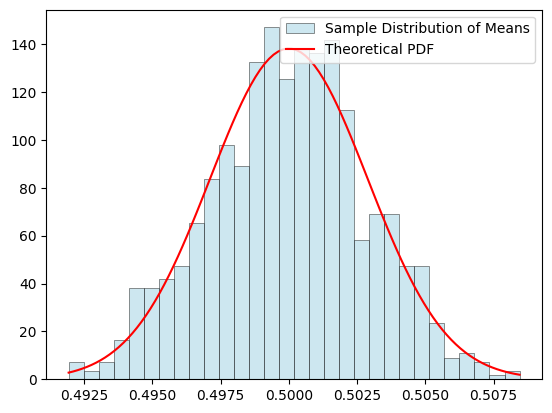

理论期望: 0.500000
实际均值: 0.499992

理论方差: 0.00000833
实际方差: 0.00000828
相对误差: 0.59%


In [15]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 生成 n = 10000 个服从均匀分布 U (0, 1) 的随机变量，重复 m = 1000次，每次计算这 n 个变量的均值。
np.random.seed(42) # 保证结果可复现
n, m = 10000, 1000 #参数：n为样本大小，m为模拟次数
meams = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]
means = np.array(meams)

# 2. 绘制这1000 个均值的直方图,并叠加理论正态分布的概率密度曲线｡ 
# 绘制直方图
plt.hist(means, bins=30, density=True, alpha=0.6, color='lightblue', label='Sample Distribution of Means',edgecolor='black', linewidth=0.5)
# 计算理论正态分布参数（均匀分布U(0,1)：均值0.5，方差1/12，样本均值方差=1/(12n)）
mu = 0.5; sigma = np.sqrt(1/(12*n))       
x = np.linspace(means.min(), means.max(), 100)     
y = norm.pdf(x, mu, sigma)
# 叠加理论正态分布概率密度曲线
plt.plot(x, y, 'r-', label='Theoretical PDF')
plt.legend();plt.show()

# 3. 计算这些均值的实际方差｡ 
actual_variance = np.var(means, ddof=1)
theory_variance = 1 / (12 * n)

print(f"理论期望: {mu:.6f}")
print(f"实际均值: {np.mean(means):.6f}")
print(f"\n理论方差: {theory_variance:.8f}")
print(f"实际方差: {actual_variance:.8f}")
print(f"相对误差: {abs(actual_variance - theory_variance)/theory_variance * 100:.2f}%")



# 导数､反向传播和复杂度 
## 理论计算  
给定函数z = (w1x1 + w2x2 −y)2,其中x1 = 2, x2 = 1, y = 3 为常数, w1, w2 为变量｡   
**1. 分别计算 ∂z/∂w1 和 ∂z/∂w2 的表达式｡**

首先，定义函数 z：
$$z = (w_1 x_1 + w_2 x_2 - y)^2$$
计算 ∂z/∂w1：
$$\frac{\partial z}{\partial w_1} = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_1$$
计算 ∂z/∂w2：
$$\frac{\partial z}{\partial w_2} = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_2$$

**2. 若当前w1 = 0.5, w2 = 1,计算梯度值｡**  
将 w1 = 0.5 和 w2 = 1 代入梯度表达式中：
$$\frac{\partial z}{\partial w_1} = 2(0.5 \cdot 2 + 1 \cdot 1 - 3) \cdot 2 = 2(-1) \cdot 2 = -4$$
$$\frac{\partial z}{\partial w_2} = 2(0.5 \cdot 2 + 1 \cdot 1 - 3) \cdot 1 = 2(-1) = -2$$
$$\text{梯度值} = \left( \frac{\partial z}{\partial w_1}, \frac{\partial z}{\partial w_2} \right) = (-4, -2)$$


## 编程题
手动实现一个简单计算图的反向传播:

In [20]:
import torch

#给定x, w1, w2 = 2.0, 1.5, 0.5，计算结果
x, w1, w2 = 2.0, 1.5, 0.5

# 手动前向
a = x * w1
b = a + w2
L = b ** 2


print(f"前向 L = {L}")

# 手动反向（链式法则）
# dL/db = 2b, db/da = 1, da/dw1 = x, db/dw2 = 1
b_val = b
grad_w1_manual = 2 * b_val * x   # 2b * x
grad_w2_manual = 2 * b_val       # 2b
print(f"手动梯度: dw1={grad_w1_manual}, dw2={grad_w2_manual}")

# PyTorch 验证
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
x_t = torch.tensor(x)
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()
print(f"PyTorch 梯度: dw1={w1_t.grad.item()}, dw2={w2_t.grad.item()}")
print(f"w1梯度一致: {abs(grad_w1_manual - w1_t.grad.item()) < 1e-6}")
print(f"w2梯度一致: {abs(grad_w2_manual - w2_t.grad.item()) < 1e-6}")

前向 L = 12.25
手动梯度: dw1=14.0, dw2=7.0
PyTorch 梯度: dw1=14.0, dw2=7.0
w1梯度一致: True
w2梯度一致: True


# 线性方法､基础优化和softmax 回归
## 理论计算
考虑线性回归模型 \(y=w x+b\) ,使用均方误差损失 
$$L=\frac{1}{n} \sum_{i=1}^{n}\left(y_{i}-\left(w x_{i}+b\right)\right)^{2}
$$
推导损失对 w 和 b 的偏导数表达式(用求和形式)｡  

计算 ∂L/∂w：    
$\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2 (y_i - (w x_i + b)) (-x_i) = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - w x_i - b)$   

计算 ∂L/∂b：    
$\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2 (y_i - (w x_i + b)) (-1) = -\frac{2}{n} \sum_{i=1}^{n} (y_i - w x_i - b)$


## 编程题
从零实现 softmax 回归对手写数字（MNIST）进行分类：
1. 使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集。
2. 将图像展平为向量，对标签进行 one‑hot 编码。
3. 实现 softmax 函数、交叉熵损失函数。
4. 使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个
epoch。
5. 输出测试集上的准确率

In [21]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 设置随机种子
np.random.seed(42)

# 1. 加载MNIST子集 (8x8图像)
digits = load_digits()
X, y = digits.data, digits.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 数据标准化
X_train = X_train / 16.0  # 像素值范围0-16
X_test = X_test / 16.0

# 2. 图像已展平为64维向量，对标签进行one-hot编码
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

n_classes = 10
n_features = X_train.shape[1]

# 3. 实现softmax函数和交叉熵损失
def softmax(z):
    """稳定的softmax实现"""
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失"""
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def compute_accuracy(X, y_true_labels, W, b):
    """计算准确率"""
    logits = X @ W + b
    y_pred = softmax(logits)
    pred_labels = np.argmax(y_pred, axis=1)
    return np.mean(pred_labels == y_true_labels)

# 初始化参数
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

# 4. 小批量随机梯度下降训练
batch_size = 32
learning_rate = 0.1
n_epochs = 50
n_samples = X_train.shape[0]

print("开始训练...")
for epoch in range(n_epochs):
    # 随机打乱数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    n_batches = 0
    
    for i in range(0, n_samples, batch_size):
        # 获取小批量
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        n_batches += 1
        
        # 反向传播
        grad_logits = (y_pred - y_batch) / X_batch.shape[0]
        grad_W = X_batch.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)
        
        # 参数更新
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b
    
    # 每10个epoch打印一次
    if (epoch + 1) % 10 == 0:
        train_acc = compute_accuracy(X_train, y_train, W, b)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/n_batches:.4f}, Train Acc: {train_acc:.4f}")

# 5. 测试集准确率
test_accuracy = compute_accuracy(X_test, y_test, W, b)
print(f"\n测试集准确率: {test_accuracy:.4f}")


开始训练...
Epoch 10/50, Loss: 0.4573, Train Acc: 0.9388
Epoch 20/50, Loss: 0.3004, Train Acc: 0.9534
Epoch 30/50, Loss: 0.2404, Train Acc: 0.9562
Epoch 40/50, Loss: 0.2078, Train Acc: 0.9610
Epoch 50/50, Loss: 0.1859, Train Acc: 0.9687

测试集准确率: 0.9583


# 最大似然估计和逻辑回归
## 理论计算
假设样本 $(x_{1}, x_{2}, ..., x_{n})$ 独立同分布于正态分布 $N(\mu, \sigma^{2})$ 。  
**1. 写出样本的似然函数 $L(\mu, \sigma^{2})$｡**     
样本的似然函数为：
$$L(\mu, \sigma^{2}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^{2}}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^{2}}\right) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2\right)$$

**2. 证明: μ 的最大似然估计为 $\hat{\mu}=\frac{1}{n} \sum_{i=1}^{n} x_{i}$ 。**     
首先，定义样本的对数似然函数：
$\ell(\mu, \sigma^{2}) = \ln L(\mu, \sigma^{2})$    
$\ell(\mu, \sigma^{2}) = -\frac{n}{2} \ln(2\pi\sigma^{2}) - \frac{1}{2\sigma^{2}} \sum_{i=1}^{n} (x_i - \mu)^2$     
对 μ 求导数并设为零：   
$\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu) = 0$    $\Longrightarrow\; \sum_{i=1}^{n}x_i - n\mu = 0$    
解得：
$\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i$    

**3. 证明: $\sigma^{2}$ 的最大似然估计为 $\hat{\sigma}^{2}=\frac{1}{n} \sum_{i=1}^{n}(x_{i}-\hat{\mu})^{2}$ 。**    
令 $\theta = \sigma^2$，则对数似然函数为：
$\ell(\mu, \theta) = -\frac{n}{2} \ln(2\pi\theta) - \frac{1}{2\theta} \sum_{i=1}^{n} (x_i - \mu)^2$    
对 $\theta$ 求导数并设为零：
$\frac{\partial \ell}{\partial \theta} = -\frac{n}{2\theta} + \frac{1}{2\theta^2} \sum_{i=1}^{n} (x_i - \mu)^2 = 0$    
解得：
$\theta = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2$    
因此，$\sigma^2$ 的最大似然估计为样本方差 $\hat{\sigma}^{2}$ 。


## 编程题
实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：
1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b。
4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类
准确率。

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# 1. 生成两类线性可分数据
def generate_data(n_samples, mean1, mean2, cov, seed=None):
    if seed:
        np.random.seed(seed)
    
    # 类别0
    X0 = np.random.multivariate_normal(mean1, cov, n_samples)
    y0 = np.zeros(n_samples)
    
    # 类别1
    X1 = np.random.multivariate_normal(mean2, cov, n_samples)
    y1 = np.ones(n_samples)
    
    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    
    return X, y

# 生成训练数据 (每类200个样本，2维特征)
mean1 = [-2, -2]
mean2 = [2, 2]
cov = [[1, 0.5], [0.5, 1]]

X_train, y_train = generate_data(200, mean1, mean2, cov, seed=42)

# 生成测试数据 (每类50个样本)
X_test, y_test = generate_data(50, mean1, mean2, cov, seed=123)

In [26]:

# 2. 定义sigmoid函数和二元交叉熵损失
def sigmoid(z):
    # 防止溢出
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


训练完成!
参数 w = [1.57792877 2.05149382]
参数 b = 0.121229


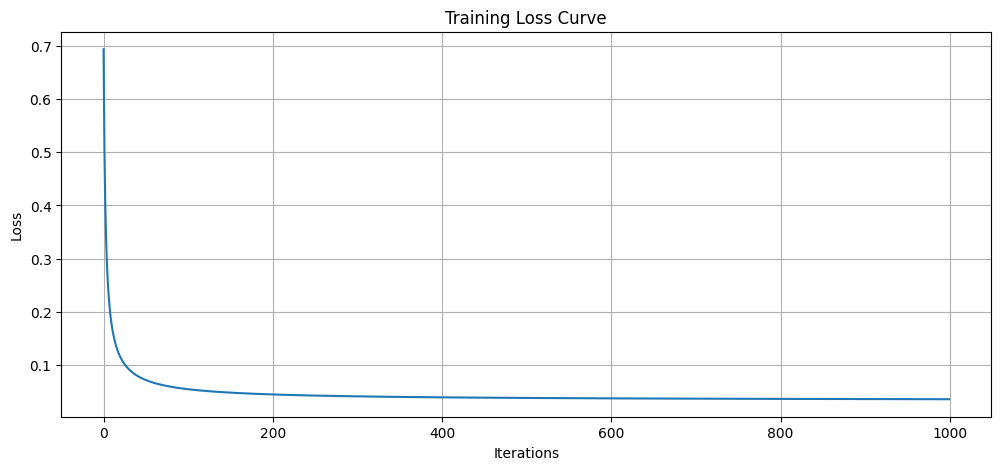

In [31]:
# 3. 梯度下降法训练逻辑回归
def train_logistic_regression(X, y, lr=0.1, n_iter=1000):
    n_samples, n_features = X.shape
    
    # 初始化参数
    w = np.zeros(n_features)
    b = 0
    
    losses = []
    
    for i in range(n_iter):
        # 前向传播
        z = X @ w + b
        y_pred = sigmoid(z)
        
        # 计算损失
        loss = binary_cross_entropy(y_pred, y)
        losses.append(loss)
        
        # 反向传播
        dz = y_pred - y
        dw = (X.T @ dz) / n_samples
        db = np.mean(dz)
        
        # 参数更新
        w -= lr * dw
        b -= lr * db
    
    return w, b, losses

# 训练模型
w, b, losses = train_logistic_regression(X_train, y_train, lr=0.1, n_iter=1000)

print(f"训练完成!")
print(f"参数 w = {w}")
print(f"参数 b = {b:.6f}")

plt.figure(figsize=(12, 5))
plt.plot(losses)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)

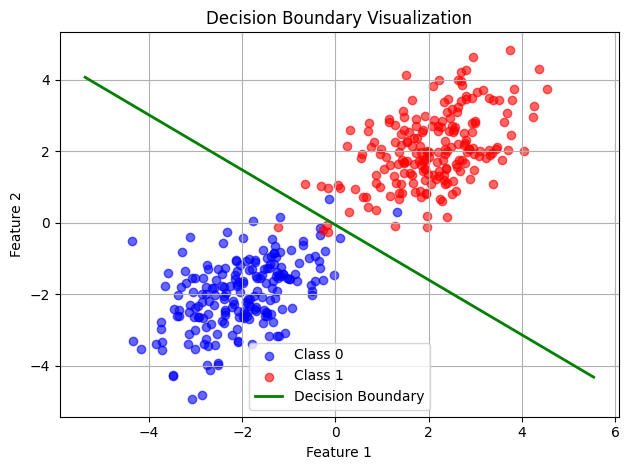


测试集分类准确率: 0.9900


In [32]:
# 4. 绘制决策边界
# 绘制训练集数据点
plt.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][:, 1], 
           c='blue', label='Class 0', alpha=0.6)
plt.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][:, 1], 
           c='red', label='Class 1', alpha=0.6)

# 绘制决策边界: w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b)/w[1]
x_boundary = np.linspace(X_train[:, 0].min()-1, X_train[:, 0].max()+1, 100)
y_boundary = -(w[0] * x_boundary + b) / w[1]

plt.plot(x_boundary, y_boundary, 'g-', linewidth=2, label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary Visualization')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 计算测试集准确率
def predict(X, w, b):
    z = X @ w + b
    y_pred = sigmoid(z)
    return (y_pred >= 0.5).astype(int)

y_pred_test = predict(X_test, w, b)
test_accuracy = np.mean(y_pred_test == y_test)

print(f"\n测试集分类准确率: {test_accuracy:.4f}")
